In [34]:
import numpy as np 
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [59]:
df=pd.read_csv(r"C:\Users\HP\Desktop\heart.csv")

In [70]:
df


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [71]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease', ylabel='Count'>

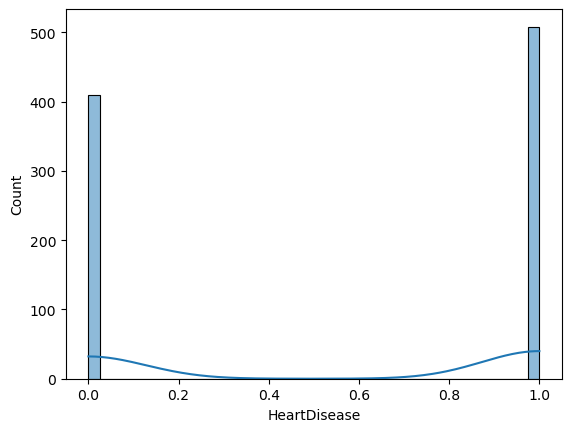

In [72]:
sns.histplot(df["HeartDisease"],bins=40,kde=True)

In [73]:
df.corr(numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [74]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [76]:
x_one_encode=pd.get_dummies(df,columns=['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope','HeartDisease'],drop_first=True)
x_one_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease_1
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True,False
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False,True
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True,False
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False,True
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,True,False,False,True,True,False,False,True,False,True
914,68,144,193,1,141,3.4,True,False,False,False,True,False,False,True,False,True
915,57,130,131,0,115,1.2,True,False,False,False,True,False,True,True,False,True
916,57,130,236,0,174,0.0,False,True,False,False,False,False,False,True,False,True


In [90]:
x_one_encode=x_one_encode.astype(int)
x_one_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease_1
0,40,140,289,0,172,0,1,1,0,0,1,0,0,0,1,0
1,49,160,180,0,156,1,0,0,1,0,1,0,0,1,0,1
2,37,130,283,0,98,0,1,1,0,0,0,1,0,0,1,0
3,48,138,214,0,108,1,0,0,0,0,1,0,1,1,0,1
4,54,150,195,0,122,0,1,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,0,1,1,0,0,1,0,1
914,68,144,193,1,141,3,1,0,0,0,1,0,0,1,0,1
915,57,130,131,0,115,1,1,0,0,0,1,0,1,1,0,1
916,57,130,236,0,174,0,0,1,0,0,0,0,0,1,0,1


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn. linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn. tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [79]:
x_one_encode.columns


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up', 'HeartDisease_1'],
      dtype='object')

In [94]:
X = x_one_encode.drop('HeartDisease_1', axis = 1)
y= x_one_encode['HeartDisease_1' ]


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,0,1,0,0,0,0,0,1,0


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [110]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [111]:
models = {
"logistic Regression" : LogisticRegression(),
"KNN" : KNeighborsClassifier(),
"Naive Byeas": GaussianNB(),
"Decision tree" : DecisionTreeClassifier(),
"SVM" : SVC()
}

In [112]:
result=[]

In [113]:
for name,model in models.items():
   model.fit(x_train_scaled,y_train)
   y_pred=model.predict(x_test_scaled)
   acc=accuracy_score(y_test,y_pred)
   f1=f1_score(y_test,y_pred)
   result.append({
     'Model':name,
     'accuracy':round(acc,4),
     'F1_score': round(f1,4)
})

In [114]:
result

[{'Model': 'logistic Regression', 'accuracy': 0.8533, 'F1_score': 0.8696},
 {'Model': 'KNN', 'accuracy': 0.8478, 'F1_score': 0.8641},
 {'Model': 'Naive Byeas', 'accuracy': 0.8641, 'F1_score': 0.8792},
 {'Model': 'Decision tree', 'accuracy': 0.788, 'F1_score': 0.8134},
 {'Model': 'SVM', 'accuracy': 0.8804, 'F1_score': 0.8962}]

In [115]:
import joblib
joblib.dump (models [ 'SVM' ], 'SVM_heart.pkl')
joblib. dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']